# 03 — Implementación de Modelos (Smoke Test)

Notebook de validación rápida de los tres modelos implementados en `src/models.py`.
Solo corre el escenario **10% etiquetado** para verificar que todo funciona antes del experimento final (notebook 04).

| Modelo | Clase |
|---|---|
| Baseline supervisado | `SupervisedBaseline` (GMM + RF) |
| GMM semi-supervisado | `SemiSupervisedGMM` (EM manual) |
| K-Means restringido | `ConstrainedKMeans` (COP-KMeans) |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Resolver paths desde cualquier cwd
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from models import ConstrainedKMeans, SemiSupervisedGMM, SupervisedBaseline

print(f'Repo root: {REPO_ROOT}')
print('Imports OK')

Repo root: /Users/javiercarredano/Documents/GitHub/Lab10-MD
Imports OK


## 1. Carga de datos y split semi-supervisado

In [2]:
import json

DATA_PATH    = REPO_ROOT / 'data' / 'processed' / 'dataset_clean.csv'
MAPPING_PATH = REPO_ROOT / 'data' / 'processed' / 'class_mapping.json'

df = pd.read_csv(DATA_PATH)
feat_cols = [c for c in df.columns if c not in ('Class', 'Class_name')]
X = df[feat_cols].values
y = df['Class'].values.astype(int)

with open(MAPPING_PATH) as f:
    class_names = {int(k): v for k, v in json.load(f).items()}

print(f'X: {X.shape}  |  clases: {np.unique(y)}  |  features: {len(feat_cols)}')

X: (13543, 16)  |  clases: [0 1 2 3 4 5 6]  |  features: 16


In [3]:
LABEL_FRACTION = 0.10
TEST_SIZE      = 0.30
RANDOM_STATE   = 42

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Simular semi-supervisado: ocultar (1 - LABEL_FRACTION) de las etiquetas
rng = np.random.default_rng(RANDOM_STATE)
y_partial = y_tr.copy()
for c in np.unique(y_tr):
    idx = np.where(y_tr == c)[0]
    n_keep = max(1, int(round(LABEL_FRACTION * len(idx))))
    keep = rng.choice(idx, size=n_keep, replace=False)
    hide = np.setdiff1d(idx, keep)
    y_partial[hide] = -1

n_labeled   = (y_partial != -1).sum()
n_unlabeled = (y_partial == -1).sum()
print(f'Train: {len(X_tr)}  |  etiquetadas: {n_labeled} ({n_labeled/len(X_tr):.1%})  |  ocultas: {n_unlabeled}')
print(f'Test:  {len(X_te)}')

Train: 9480  |  etiquetadas: 947 (10.0%)  |  ocultas: 8533
Test:  4063


## 2. SupervisedBaseline — GMM + RandomForest

In [4]:
sb = SupervisedBaseline(
    n_components=7,
    covariance_type='full',
    max_iter=200,
    tol=1e-4,
    reg_covar=1e-3,
    n_estimators=100,
    random_state=RANDOM_STATE,
)
sb.fit(X_tr, y_partial)

y_pred_gmm = sb.predict(X_te)
y_pred_rf  = sb.predict_rf(X_te)

acc_gmm = accuracy_score(y_te, y_pred_gmm)
acc_rf  = accuracy_score(y_te, y_pred_rf)

print(f'SupervisedBaseline — GMM accuracy: {acc_gmm:.4f}')
print(f'SupervisedBaseline — RF  accuracy: {acc_rf:.4f}')

SupervisedBaseline — GMM accuracy: 0.8806
SupervisedBaseline — RF  accuracy: 0.9028


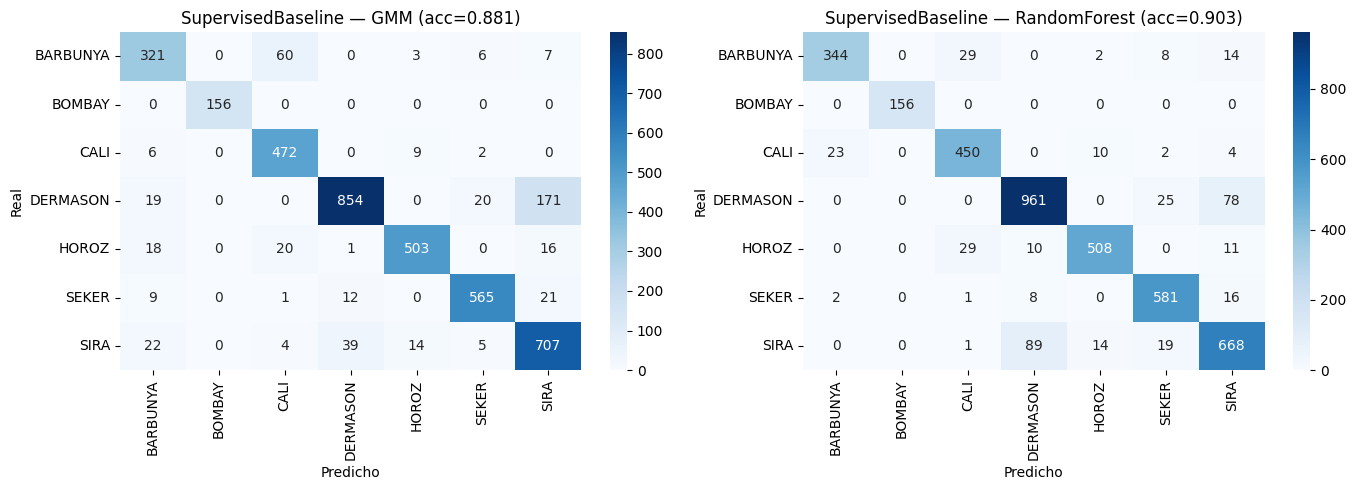

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_labels = [class_names[i] for i in range(7)]

for ax, y_pred, title in zip(
    axes,
    [y_pred_gmm, y_pred_rf],
    [f'GMM (acc={acc_gmm:.3f})', f'RandomForest (acc={acc_rf:.3f})'],
):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels, ax=ax
    )
    ax.set_title(f'SupervisedBaseline — {title}')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'results' / 'figures' / 'smoke_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. SemiSupervisedGMM — EM manual con restricciones duras

In [6]:
ss = SemiSupervisedGMM(
    n_components=7,
    covariance_type='full',
    max_iter=100,
    tol=1e-4,
    reg_covar=1e-3,
    random_state=RANDOM_STATE,
)
ss.fit(X_tr, y_partial)

y_pred_ss = ss.predict(X_te)
acc_ss = accuracy_score(y_te, y_pred_ss)

print(f'SemiSupervisedGMM accuracy: {acc_ss:.4f}  (convergió en {ss.n_iter_} iteraciones)')

SemiSupervisedGMM accuracy: 0.8892  (convergió en 12 iteraciones)


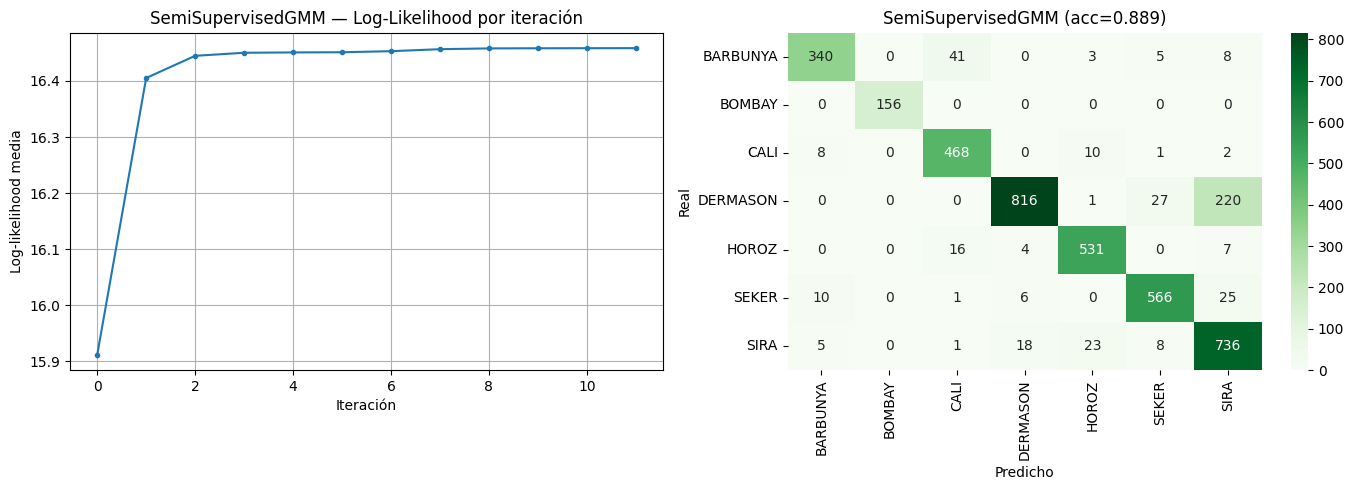

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de log-likelihood
axes[0].plot(ss.log_likelihood_history_, marker='o', markersize=3)
axes[0].set_title('SemiSupervisedGMM — Log-Likelihood por iteración')
axes[0].set_xlabel('Iteración'); axes[0].set_ylabel('Log-likelihood media')
axes[0].grid(True)

# Matriz de confusión
cm = confusion_matrix(y_te, y_pred_ss)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_labels, yticklabels=class_labels, ax=axes[1]
)
axes[1].set_title(f'SemiSupervisedGMM (acc={acc_ss:.3f})')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'results' / 'figures' / 'smoke_ssgmm.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. ConstrainedKMeans — COP-KMeans con must-link / cannot-link

In [8]:
ck = ConstrainedKMeans(
    n_clusters=7,
    max_iter=300,
    max_ml=500,
    max_cl=500,
    random_state=RANDOM_STATE,
)
ck.fit(X_tr, y_partial)

y_pred_ck = ck.predict(X_te)
acc_ck = accuracy_score(y_te, y_pred_ck)

print(f'ConstrainedKMeans accuracy: {acc_ck:.4f}')
print(f'Must-link usados:    {len(ck.ml_)}')
print(f'Cannot-link usados:  {len(ck.cl_)}')

ConstrainedKMeans accuracy: 0.7603
Must-link usados:    500
Cannot-link usados:  500


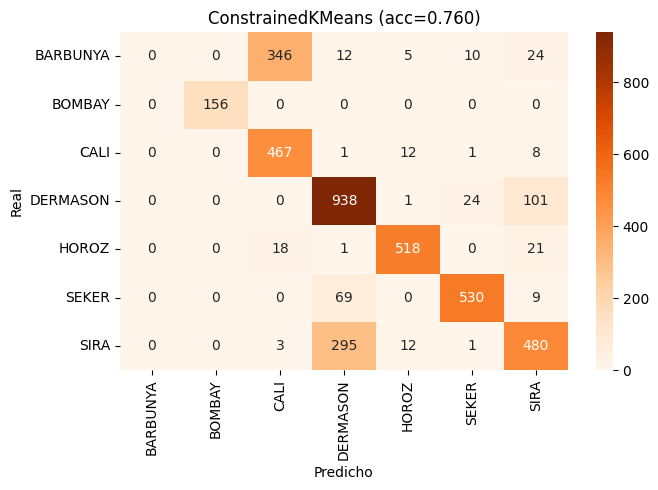

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_te, y_pred_ck)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=class_labels, yticklabels=class_labels, ax=ax
)
ax.set_title(f'ConstrainedKMeans (acc={acc_ck:.3f})')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(REPO_ROOT / 'results' / 'figures' / 'smoke_ckm.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Resumen comparativo

In [10]:
results = pd.DataFrame([
    {'Modelo': 'SupervisedBaseline (GMM)',  'Accuracy': acc_gmm, 'Tipo': 'Supervisado'},
    {'Modelo': 'SupervisedBaseline (RF)',   'Accuracy': acc_rf,  'Tipo': 'Supervisado'},
    {'Modelo': 'SemiSupervisedGMM',         'Accuracy': acc_ss,  'Tipo': 'Semi-supervisado'},
    {'Modelo': 'ConstrainedKMeans',         'Accuracy': acc_ck,  'Tipo': 'Semi-supervisado'},
])

print(results.to_string(index=False))
results.to_csv(REPO_ROOT / 'results' / 'metrics' / 'metrics_smoke.csv', index=False)
print('\nGuardado en results/metrics/metrics_smoke.csv')

                  Modelo  Accuracy             Tipo
SupervisedBaseline (GMM)  0.880630      Supervisado
 SupervisedBaseline (RF)  0.902781      Supervisado
       SemiSupervisedGMM  0.889244 Semi-supervisado
       ConstrainedKMeans  0.760276 Semi-supervisado

Guardado en results/metrics/metrics_smoke.csv


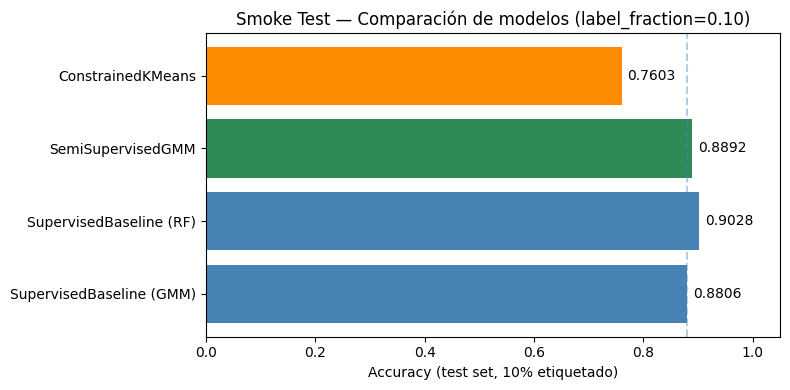

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'steelblue', 'seagreen', 'darkorange']
bars = ax.barh(results['Modelo'], results['Accuracy'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy (test set, 10% etiquetado)')
ax.set_title('Smoke Test — Comparación de modelos (label_fraction=0.10)')
ax.axvline(x=acc_gmm, color='steelblue', linestyle='--', alpha=0.4, label='Baseline GMM')
plt.tight_layout()
plt.savefig(REPO_ROOT / 'results' / 'figures' / 'smoke_comparison.png', dpi=120, bbox_inches='tight')
plt.show()